## 07 - Perbandingan CNN Scratch vs MobileNetV2

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

DIR_FIGURES = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

DIR_FIGURES.mkdir(
    parents=True,
    exist_ok=True
)

In [5]:
cnn = pd.read_csv(
    "../results/metrics/cnn_scratch_results.csv"
)

mobilenet = pd.read_csv(
    "../results/metrics/cnn_mobilenetv2_results.csv"
)

# ambil hanya hasil finetune
mobilenet = mobilenet[
    mobilenet["phase"] == "finetune"
].copy()

cnn["model"] = "CNN Scratch"
mobilenet["model"] = "MobileNetV2"

df_compare = pd.concat(
    [cnn, mobilenet],
    ignore_index=True
)

# buang kolom phase dari hasil mobilenet karena yg dipake hanya satu phase (finetune)
df_compare = df_compare.drop(
    columns=["phase"],
    errors="ignore"
)

# samakan nama skenario
df_compare["scenario"] = df_compare["scenario"].replace({
    "grabcut_original": "original_grabcut"
})

df_compare

,accuracy,precision_macro,recall_macro,f1_macro,scenario,model
0,0.5765,0.5908,0.5890,0.5842,original,CNN Scratch
1,0.5946,0.6153,0.6018,0.6015,clahe,CNN Scratch
2,0.6465,0.6640,0.6626,0.6579,clahe_gaussian,CNN Scratch
3,0.5609,0.5928,0.5539,0.5639,original_grabcut,CNN Scratch
4,0.8894,0.8956,0.8957,0.8955,original,MobileNetV2
5,0.8790,0.8872,0.8876,0.8865,clahe,MobileNetV2
6,0.8755,0.8815,0.8828,0.8818,clahe_gaussian,MobileNetV2
7,0.8021,0.7957,0.8120,0.7994,original_grabcut,MobileNetV2


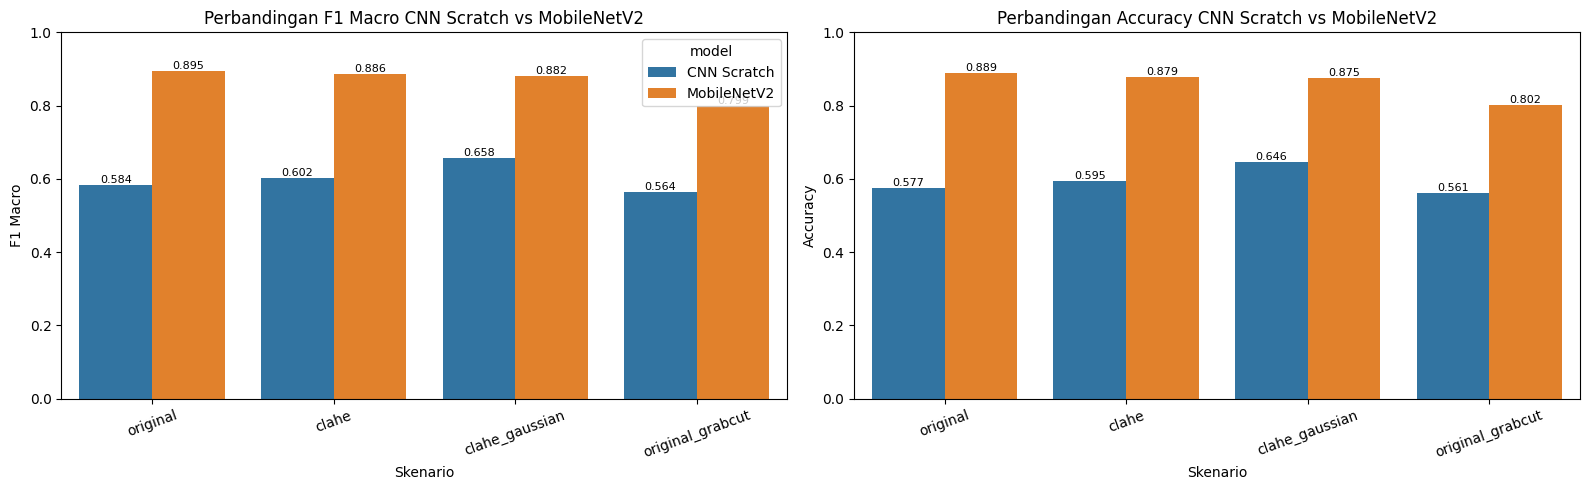

In [6]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)

# F1 MACRO
sns.barplot(
    data=df_compare,
    x="scenario",
    y="f1_macro",
    hue="model",
    ax=ax[0]
)

ax[0].set_title(
    "Perbandingan F1 Macro CNN Scratch vs MobileNetV2"
)

ax[0].set_xlabel("Skenario")
ax[0].set_ylabel("F1 Macro")
ax[0].set_ylim(0, 1)

for container in ax[0].containers:
    ax[0].bar_label(
        container,
        fmt="%.3f",
        fontsize=8
    )

# ACCURACY
sns.barplot(
    data=df_compare,
    x="scenario",
    y="accuracy",
    hue="model",
    ax=ax[1]
)

ax[1].set_title(
    "Perbandingan Accuracy CNN Scratch vs MobileNetV2"
)

ax[1].set_xlabel("Skenario")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0, 1)

for container in ax[1].containers:
    ax[1].bar_label(
        container,
        fmt="%.3f",
        fontsize=8
    )

# RAPIIIN
for a in ax:
    a.tick_params(
        axis="x",
        rotation=20
    )

# hapus legend kanan supaya tidak dobel
ax[1].legend_.remove()

plt.tight_layout()

plt.savefig(
    DIR_FIGURES / "cnn_vs_mobilenet_comparison.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

## Inferensi Semua Model

Masukkan path gambar pada `IMAGE_PATH`, atau gunakan tombol upload jika `ipywidgets` tersedia. Cell akan menjalankan prediksi pada semua model yang bisa dimuat dari folder `models`.


Model berhasil dimuat: 8 dari 8
Gambar input diprediksi mayoritas sebagai: biological
Prediksi confidence tertinggi: glass (MobileNetV2 - original, 83.30%)


,model,scenario,prediksi,confidence
0,CNN Scratch,clahe,metal,24.51%
1,CNN Scratch,clahe_gaussian,paper,46.85%
2,CNN Scratch,original,biological,45.83%
3,CNN Scratch,original_grabcut,biological,26.97%
4,MobileNetV2,clahe,glass,63.93%
5,MobileNetV2,clahe_gaussian,metal,53.01%
6,MobileNetV2,original,glass,83.30%
7,MobileNetV2,original_grabcut,plastic,46.82%


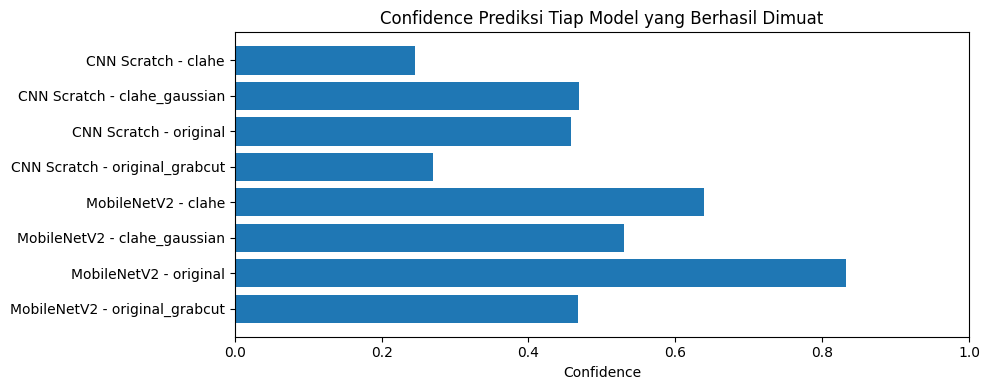

Gambar input setelah dilewati preprocessing tiap model:


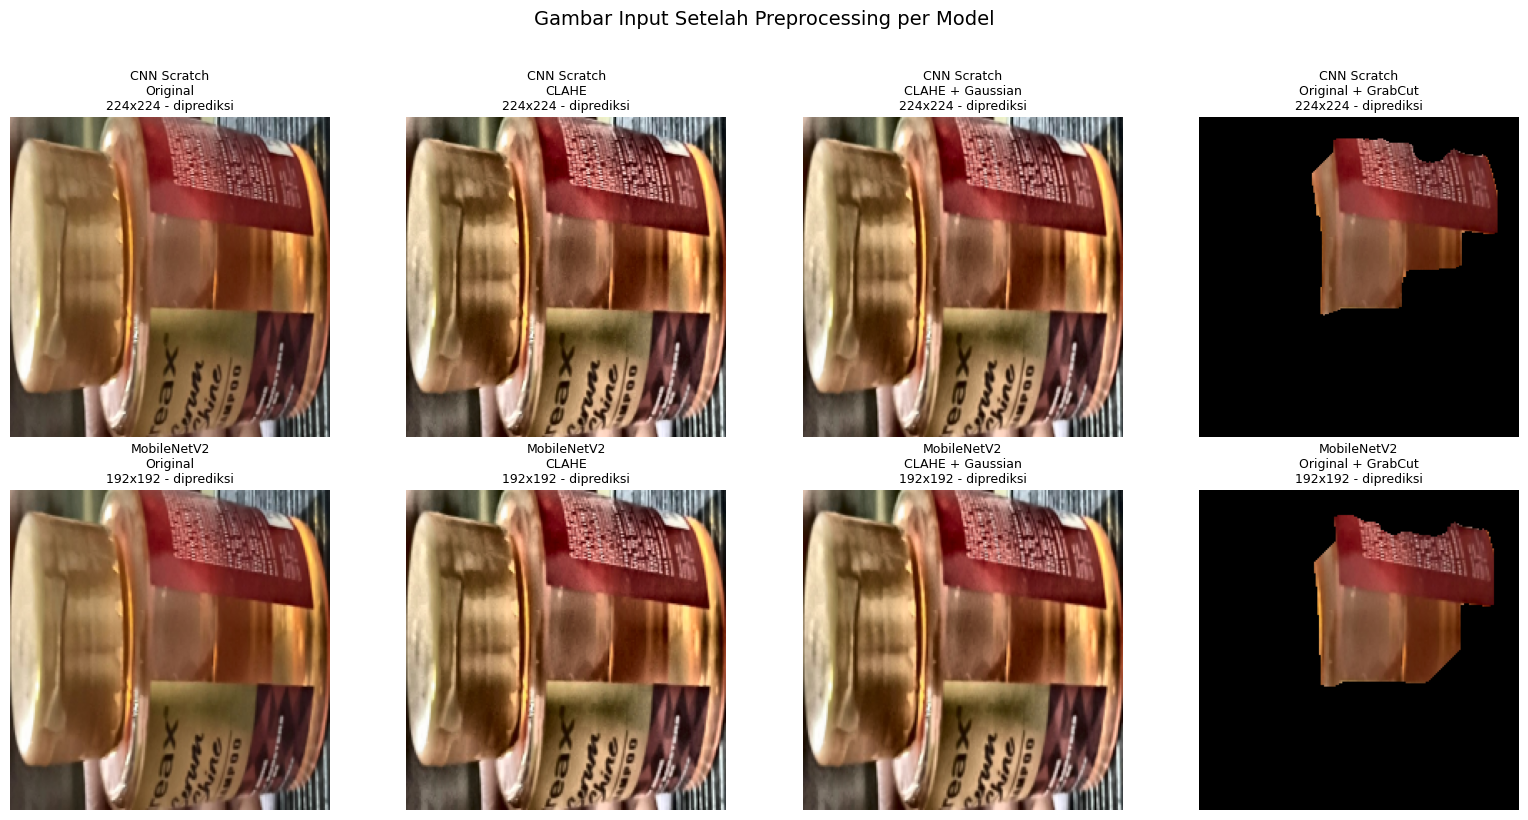

In [3]:
import io
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from IPython.display import display, clear_output

CURRENT_DIR = Path.cwd().resolve()
if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
elif (CURRENT_DIR / "models").exists():
    PROJECT_ROOT = CURRENT_DIR
else:
    PROJECT_ROOT = Path("..").resolve()

DIR_MODELS = PROJECT_ROOT / "models"

CLASS_NAMES = [
    "biological",
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
]

MODEL_CONFIGS = [
    {
        "model": "CNN Scratch",
        "scenario": "original",
        "path": DIR_MODELS / "cnn_original_baseline.keras",
        "default_input_size": (224, 224),
    },
    {
        "model": "CNN Scratch",
        "scenario": "clahe",
        "path": DIR_MODELS / "cnn_clahe.keras",
        "default_input_size": (224, 224),
    },
    {
        "model": "CNN Scratch",
        "scenario": "clahe_gaussian",
        "path": DIR_MODELS / "cnn_clahe_gaussian.keras",
        "default_input_size": (224, 224),
    },
    {
        "model": "CNN Scratch",
        "scenario": "original_grabcut",
        "path": DIR_MODELS / "cnn_grabcut.keras",
        "default_input_size": (224, 224),
    },
    {
        "model": "MobileNetV2",
        "scenario": "original",
        "path": DIR_MODELS / "original_finetune.keras",
        "default_input_size": (192, 192),
    },
    {
        "model": "MobileNetV2",
        "scenario": "clahe",
        "path": DIR_MODELS / "clahe_finetune.keras",
        "default_input_size": (192, 192),
    },
    {
        "model": "MobileNetV2",
        "scenario": "clahe_gaussian",
        "path": DIR_MODELS / "clahe_gaussian_finetune.keras",
        "default_input_size": (192, 192),
    },
    {
        "model": "MobileNetV2",
        "scenario": "original_grabcut",
        "path": DIR_MODELS / "grabcut_original_finetune.keras",
        "default_input_size": (192, 192),
    },
]

SCENARIO_LABELS = {
    "original": "Original",
    "clahe": "CLAHE",
    "clahe_gaussian": "CLAHE + Gaussian",
    "original_grabcut": "Original + GrabCut",
}

# Set False kalau ingin tabel prediksi saja tanpa visualisasi gambar preprocessing.
SHOW_PROCESSED_IMAGES = True

# Cache supaya rerun cell/prediksi/upload berikutnya tidak load model ulang dari disk.
_LOADED_MODELS_CACHE = globals().get("_LOADED_MODELS_CACHE")
_SKIPPED_MODELS_CACHE = globals().get("_SKIPPED_MODELS_CACHE")


def is_git_lfs_pointer(path):
    if not path.exists() or path.stat().st_size > 1024:
        return False

    try:
        return path.read_text(encoding="utf-8", errors="ignore").startswith(
            "version https://git-lfs.github.com/spec/v1"
        )
    except OSError:
        return False


def get_model_input_size(model):
    shape = model.input_shape
    if isinstance(shape, list):
        shape = shape[0]

    height, width = shape[1], shape[2]
    if height is None or width is None:
        return None

    return (height, width)


def load_rgb_from_path(image_path):
    img = keras.utils.load_img(
        image_path,
        color_mode="rgb",
    )
    return keras.utils.img_to_array(img).astype(np.uint8)


def load_rgb_from_bytes(image_bytes):
    img = keras.utils.load_img(
        io.BytesIO(image_bytes),
        color_mode="rgb",
    )
    return keras.utils.img_to_array(img).astype(np.uint8)


def apply_clahe_rgb(image_rgb):
    lab = cv2.cvtColor(
        image_rgb,
        cv2.COLOR_RGB2LAB,
    )
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8),
    )
    l = clahe.apply(l)

    merged = cv2.merge((l, a, b))
    return cv2.cvtColor(
        merged,
        cv2.COLOR_LAB2RGB,
    )


def apply_clahe_gaussian_rgb(image_rgb):
    image_rgb = apply_clahe_rgb(image_rgb)
    return cv2.GaussianBlur(
        image_rgb,
        (3, 3),
        0,
    )


def buat_rect_otomatis(width, height, margin=15):
    margin = int(min(margin, width // 2 - 1, height // 2 - 1))
    margin = max(margin, 1)
    return (margin, margin, width - 2 * margin, height - 2 * margin)


def apply_grabcut_rgb(image_rgb, target_size=(224, 224), margin=15, iterasi=5, kernel_size=5):
    image_bgr = cv2.cvtColor(
        image_rgb,
        cv2.COLOR_RGB2BGR,
    )
    image_bgr = cv2.resize(
        image_bgr,
        target_size,
        interpolation=cv2.INTER_AREA,
    )

    height, width = image_bgr.shape[:2]
    mask = np.zeros((height, width), np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)
    rect = buat_rect_otomatis(width, height, margin)

    cv2.grabCut(
        image_bgr,
        mask,
        rect,
        bgd_model,
        fgd_model,
        iterasi,
        cv2.GC_INIT_WITH_RECT,
    )

    mask_grabcut = np.where(
        (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD),
        255,
        0,
    ).astype("uint8")

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (kernel_size, kernel_size),
    )
    mask_clean = cv2.morphologyEx(
        mask_grabcut,
        cv2.MORPH_OPEN,
        kernel,
    )
    mask_clean = cv2.morphologyEx(
        mask_clean,
        cv2.MORPH_CLOSE,
        kernel,
    )

    contours, _ = cv2.findContours(
        mask_clean,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )
    if contours:
        largest = max(contours, key=cv2.contourArea)
        mask_object = np.zeros_like(mask_clean)
        cv2.drawContours(
            mask_object,
            [largest],
            -1,
            255,
            thickness=cv2.FILLED,
        )
    else:
        mask_object = mask_clean

    mask_bin = (mask_object > 0).astype("uint8")
    segmented_bgr = cv2.bitwise_and(
        image_bgr,
        image_bgr,
        mask=mask_bin,
    )
    return cv2.cvtColor(
        segmented_bgr,
        cv2.COLOR_BGR2RGB,
    )


def preprocess_for_scenario(image_rgb, scenario, target_size):
    if scenario == "original":
        processed = image_rgb
    elif scenario == "clahe":
        processed = apply_clahe_rgb(image_rgb)
    elif scenario == "clahe_gaussian":
        processed = apply_clahe_gaussian_rgb(image_rgb)
    elif scenario == "original_grabcut":
        return apply_grabcut_rgb(
            image_rgb,
            target_size=target_size,
        )
    else:
        raise ValueError(f"Skenario tidak dikenal: {scenario}")

    return cv2.resize(
        processed,
        target_size,
        interpolation=cv2.INTER_AREA,
    )


def load_available_models(force_reload=False):
    global _LOADED_MODELS_CACHE, _SKIPPED_MODELS_CACHE

    if (
        not force_reload
        and _LOADED_MODELS_CACHE is not None
        and _SKIPPED_MODELS_CACHE is not None
    ):
        return _LOADED_MODELS_CACHE, _SKIPPED_MODELS_CACHE

    loaded = []
    skipped = []

    for config in MODEL_CONFIGS:
        model_path = config["path"]

        if not model_path.exists():
            skipped.append({**config, "reason": "file model tidak ditemukan"})
            continue

        if is_git_lfs_pointer(model_path):
            skipped.append({**config, "reason": "file masih Git LFS pointer, belum berisi bobot asli"})
            continue

        try:
            model = keras.models.load_model(model_path)
            loaded.append({**config, "loaded_model": model})
        except Exception as exc:
            skipped.append({**config, "reason": str(exc)})

    _LOADED_MODELS_CACHE = loaded
    _SKIPPED_MODELS_CACHE = skipped
    print(f"Model berhasil dimuat: {len(loaded)} dari {len(MODEL_CONFIGS)}")

    return loaded, skipped


def clear_model_cache():
    global _LOADED_MODELS_CACHE, _SKIPPED_MODELS_CACHE
    _LOADED_MODELS_CACHE = None
    _SKIPPED_MODELS_CACHE = None
    keras.backend.clear_session()
    print("Cache model dikosongkan.")


def plot_processed_inputs(processed_images):
    if not processed_images:
        return

    cols = 4
    rows = int(np.ceil(len(processed_images) / cols))
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4 * cols, 4 * rows),
    )
    axes = np.array(axes).reshape(-1)

    for ax, item in zip(axes, processed_images):
        ax.imshow(item["image"].astype(np.uint8))
        ax.axis("off")
        ax.set_title(
            f"{item['model']}\n"
            f"{SCENARIO_LABELS[item['scenario']]}\n"
            f"{item['target_size'][0]}x{item['target_size'][1]} - {item['status']}",
            fontsize=9,
        )

    for ax in axes[len(processed_images):]:
        ax.axis("off")

    plt.suptitle(
        "Gambar Input Setelah Preprocessing per Model",
        y=1.02,
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()


def predict_with_all_models(image_source, source_type="path"):
    if source_type == "bytes":
        image_rgb = load_rgb_from_bytes(image_source)
    else:
        image_rgb = load_rgb_from_path(image_source)

    loaded_models, skipped_models = load_available_models(force_reload=False)
    loaded_by_key = {
        (item["model"], item["scenario"]): item
        for item in loaded_models
    }

    rows = []
    processed_images = []
    preprocess_cache = {}

    for config in MODEL_CONFIGS:
        key = (config["model"], config["scenario"])
        loaded_item = loaded_by_key.get(key)

        target_size = config["default_input_size"]
        if loaded_item is not None:
            detected_size = get_model_input_size(loaded_item["loaded_model"])
            if detected_size is not None:
                target_size = detected_size

        preprocess_key = (config["scenario"], target_size)
        if preprocess_key not in preprocess_cache:
            preprocess_cache[preprocess_key] = preprocess_for_scenario(
                image_rgb,
                config["scenario"],
                target_size,
            )
        processed_rgb = preprocess_cache[preprocess_key]

        status = "diprediksi" if loaded_item is not None else "dilewati"
        if SHOW_PROCESSED_IMAGES:
            processed_images.append({
                "model": config["model"],
                "scenario": config["scenario"],
                "target_size": target_size,
                "status": status,
                "image": processed_rgb,
            })

        if loaded_item is None:
            continue

        batch = np.expand_dims(
            processed_rgb.astype(np.float32),
            axis=0,
        )
        probs = loaded_item["loaded_model"].predict(batch, verbose=0)[0]
        pred_idx = int(np.argmax(probs))

        rows.append({
            "model": config["model"],
            "scenario": config["scenario"],
            "prediksi": CLASS_NAMES[pred_idx],
            "confidence": float(probs[pred_idx]),
            **{f"prob_{name}": float(probs[i]) for i, name in enumerate(CLASS_NAMES)},
        })

    result = pd.DataFrame(rows)
    if len(result) > 0:
        result = result.sort_values(
            ["model", "scenario"],
            ignore_index=True,
        )

        majority_pred = result["prediksi"].mode().iloc[0]
        top_row = result.sort_values(
            "confidence",
            ascending=False,
        ).iloc[0]

        print(f"Gambar input diprediksi mayoritas sebagai: {majority_pred}")
        print(
            "Prediksi confidence tertinggi: "
            f"{top_row['prediksi']} "
            f"({top_row['model']} - {top_row['scenario']}, "
            f"{top_row['confidence']:.2%})"
        )

        display(
            result[["model", "scenario", "prediksi", "confidence"]].style.format({
                "confidence": "{:.2%}",
            })
        )

        plot_df = result.copy()
        plot_df["label"] = plot_df["model"] + " - " + plot_df["scenario"]

        plt.figure(figsize=(10, max(4, 0.5 * len(plot_df))))
        plt.barh(plot_df["label"], plot_df["confidence"])
        plt.xlim(0, 1)
        plt.xlabel("Confidence")
        plt.title("Confidence Prediksi Tiap Model yang Berhasil Dimuat")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print("Tidak ada model yang berhasil dimuat.")

    if SHOW_PROCESSED_IMAGES:
        print("Gambar input setelah dilewati preprocessing tiap model:")
        plot_processed_inputs(processed_images)

    if skipped_models:
        skipped = pd.DataFrame([
            {
                "model": item["model"],
                "scenario": item["scenario"],
                "path": str(item["path"]),
                "reason": item["reason"],
            }
            for item in skipped_models
        ])
        print("Model yang dilewati:")
        display(skipped)

    return result


# Ganti path ini dengan gambar yang ingin diprediksi.
IMAGE_PATH = PROJECT_ROOT / "data" / "enhanced" / "clahe" / "test" / "plastic" / "plastic_100.jpg"

if IMAGE_PATH.exists():
    hasil_prediksi = predict_with_all_models(IMAGE_PATH)
else:
    print(f"IMAGE_PATH belum ditemukan: {IMAGE_PATH}")
    print("Ganti IMAGE_PATH dengan path gambar yang ada, lalu jalankan ulang cell ini.")


# Opsional: upload gambar langsung dari notebook.
try:
    import ipywidgets as widgets

    uploader = widgets.FileUpload(
        accept="image/*",
        multiple=False,
        description="Upload gambar",
    )
    button = widgets.Button(
        description="Prediksi upload",
        button_style="primary",
    )
    output = widgets.Output()

    def get_uploaded_content(upload_value):
        if isinstance(upload_value, dict):
            uploaded_file = next(iter(upload_value.values()))
            return uploaded_file["content"]

        uploaded_file = upload_value[0]
        return uploaded_file["content"]

    def run_uploaded_prediction(_):
        with output:
            clear_output(wait=True)
            if not uploader.value:
                print("Pilih gambar dulu.")
                return

            hasil_upload = predict_with_all_models(
                get_uploaded_content(uploader.value),
                source_type="bytes",
            )
            globals()["hasil_upload"] = hasil_upload

    button.on_click(run_uploaded_prediction)
    display(widgets.VBox([uploader, button, output]))

except ImportError:
    print("ipywidgets belum tersedia. Pakai IMAGE_PATH untuk inferensi.")
